# 07 Presentation-Ready Visualizations
**Project:** Retailmart Finance Analytics  
**Phase:** Build high-quality charts for reports and dashboards.

---

### 1. Setup & Imports
We must add the parent directory to the system path so Python can locate the custom `src` modules.

In [ ]:
import sys
import os
import pandas as pd
import numpy as np

# Add root directory to python path
sys.path.append(os.path.abspath(os.path.join('..')))

# Import custom configurations and utilities
from src.config.config import config
from src.database.connection import db_connector
from src.utils.logger import setup_logger
from src.utils.helpers import save_dataframe

import matplotlib.pyplot as plt
import seaborn as sns

logger = setup_logger(os.path.splitext(os.path.basename('__file__'))[0])
logger.info('Notebook setup and imports loaded successfully.')

### 2. Define Plot Styles & Palettes
Placeholder for define plot styles & palettes steps.

In [2]:
# --- Updated styling block with direct imports ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Elegant Minimalist Finance Palette (Hex Codes)
COLOR_PRIMARY = "#0F172A"    # Deep Slate/Navy
COLOR_ACCENT = "#0EA5E9"     # Elegant Teal/Sky Blue
COLOR_TEXT = "#334155"       # Muted Slate
COLOR_GRID = "#F1F5F9"       # Whisper-thin light gray

# 2. Set global theme configurations
sns.set_theme(style="white", rc={
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "grid.color": COLOR_GRID
})

# 3. Apply global Matplotlib styling parameters
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Inter", "Helvetica", "Arial"],
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.labelcolor": COLOR_TEXT,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": COLOR_PRIMARY,
    "xtick.labelsize": 9,
    "xtick.color": COLOR_TEXT,
    "ytick.labelsize": 9,
    "ytick.color": COLOR_TEXT,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.titlesize": 15,
    "grid.linestyle": "-",
    "grid.linewidth": 1,
    "axes.spines.top": False,     # Hide top border
    "axes.spines.right": False    # Hide right border
})

print("Minimalist finance styling successfully applied globally.")

Minimalist finance styling successfully applied globally.


C:\Users\ishup\AppData\Local\Temp\ipykernel_21364\2034709208.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(chart_data["month_label"], rotation=45, ha="right")


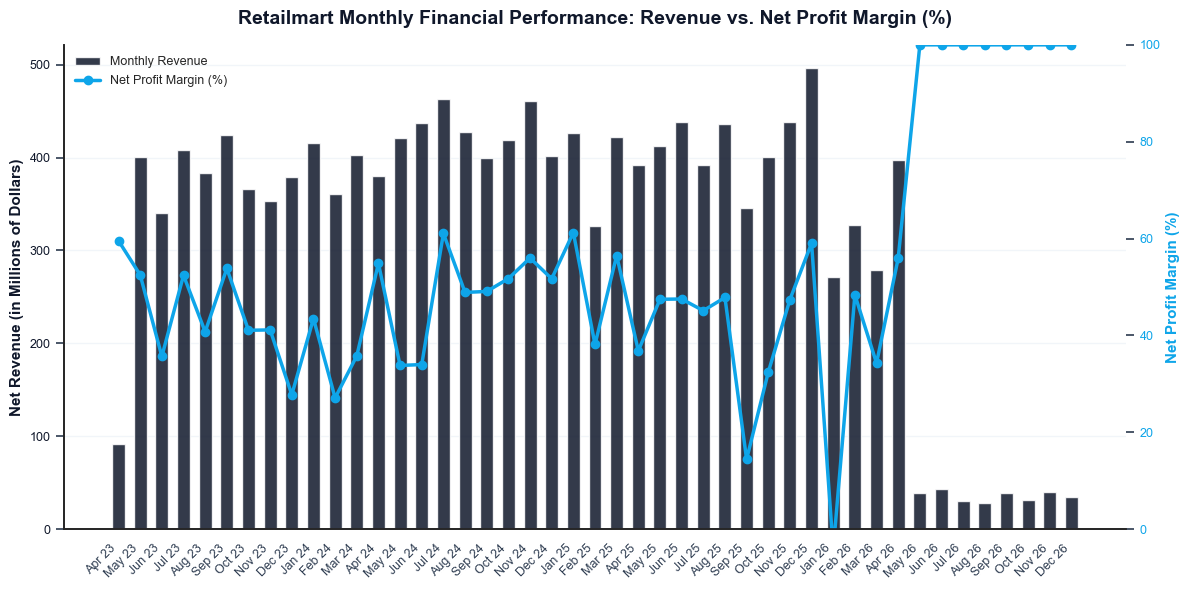

In [5]:
# --- Section 3: Executive Combo Chart (Corrected) ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load the monthly P&L summary we exported in Phase 5
processed_dir = "../data/processed"
monthly_finance = pd.read_csv(os.path.join(processed_dir, "monthly_finance_summary.csv"))

# Convert months to proper date objects (No to_timestamp() needed here!)
monthly_finance["month_date"] = pd.to_datetime(monthly_finance["month"])
monthly_finance = monthly_finance.sort_values(by="month_date")

# Exclude Q1 2023 because of the ledger data gap (zero expenses/100% margins)
chart_data = monthly_finance[monthly_finance["month"] >= "2023-04"].copy()

# Create clean date labels for the X-axis (e.g. "Apr 23")
chart_data["month_label"] = chart_data["month_date"].dt.strftime("%b %y")

# 2. Create the figure and the primary axes (Left Y-Axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Total Revenue as vertical bars (Deep Slate/Navy)
# Convert revenue to millions for clean labels
chart_data["revenue_millions"] = chart_data["total_revenue"] / 1000000.0
bars = ax1.bar(
    chart_data["month_label"], 
    chart_data["revenue_millions"], 
    color="#0F172A", 
    alpha=0.85, 
    width=0.6,
    label="Monthly Revenue"
)

# Format Left Y-Axis (Revenue)
ax1.set_ylabel("Net Revenue (in Millions of Dollars)", color="#0F172A", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#0F172A")
ax1.grid(axis="y", linestyle="-", color="#F1F5F9") # Muted horizontal grids

# 3. Create the secondary axes sharing the same X-axis (Right Y-Axis)
ax2 = ax1.twinx()

# Plot Net Profit Margin as a line chart (Sky Blue)
line = ax2.plot(
    chart_data["month_label"], 
    chart_data["net_profit_margin"], 
    color="#0EA5E9", 
    linewidth=2.5, 
    marker="o", 
    markersize=6,
    label="Net Profit Margin (%)"
)

# Format Right Y-Axis (Margin)
ax2.set_ylabel("Net Profit Margin (%)", color="#0EA5E9", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#0EA5E9")
ax2.set_ylim(0, 100) # Percentage range
ax2.grid(False) # Turn off grids for secondary axis to prevent overlapping lines

# 4. Final aesthetics: Rotate X-labels and add title
ax1.set_xticklabels(chart_data["month_label"], rotation=45, ha="right")
plt.title("Retailmart Monthly Financial Performance: Revenue vs. Net Profit Margin (%)", fontsize=14, pad=15)

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

### 3. Monthly Revenue & Profit Trends
Placeholder for monthly revenue & profit trends steps.

### 4. Regional Sales Distribution Chart
Placeholder for regional sales distribution chart steps.

### 5. KPI Summary Visualization Card Mockups
Placeholder for kpi summary visualization card mockups steps.